This notebook explore stacking of our final models that show particularly good results (XGboost, RandomForest, LogisticRegression and CatBoost)

Imports and setting

In [ ]:
import os
os.chdir("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, classification_report, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.pipeline import Pipeline

from src.data_processing.data_load import load_data_processed_from_S3
from src.models.model_saving import load_model_from_s3
from Config import S3_BUCKET_FINAL_MODELS, MLFLOW_EXPERIMENT_NAME


#Setting so catboost load succeed 
from src.models.train_catboost import CatBoostAutoCat #import catboost class created
import __main__
__main__.CatBoostAutoCat = CatBoostAutoCat  # inject class catboost in __main__

Load base models from S3

In [123]:
xgb_pipeline  = load_model_from_s3(bucket=S3_BUCKET_FINAL_MODELS, model_name="xgboost")
cat_pipeline   = load_model_from_s3(bucket=S3_BUCKET_FINAL_MODELS, model_name="catboost")
rl_pipeline = load_model_from_s3(bucket=S3_BUCKET_FINAL_MODELS, model_name="logistic_regression" )
rf_pipeline = load_model_from_s3(bucket=S3_BUCKET_FINAL_MODELS, model_name="random_forest" )

#extract the models
xgb_model= xgb_pipeline["model"]
cat_model= cat_pipeline["model"]
rl_model= rl_pipeline #we keep the full pipeline for regression logistique (scaler + model)
rf_model= rf_pipeline["model"]

Load processed datasets

In [124]:
#Let's load the dataset on which catboost and xgboost were trained and tested

#for logistic regression
X_train_enc_norm=load_data_processed_from_S3("X_train_enc_norm")
y_train_enc_norm=load_data_processed_from_S3("y_train_enc_norm").values
X_val_enc_norm=load_data_processed_from_S3("X_test_enc_norm")
y_val_enc_norm=load_data_processed_from_S3("y_test_enc_norm").values

#for xgboost and random forest
X_train_enc_nonorm=load_data_processed_from_S3("X_train_enc_nonorm")
y_train_enc_nonorm=load_data_processed_from_S3("y_train_enc_nonorm").values
X_val_enc_nonorm=load_data_processed_from_S3("X_test_enc_nonorm")
y_val_enc_nonorm=load_data_processed_from_S3("y_test_enc_nonorm").values

#for catboost
X_train_noenc_nonorm =load_data_processed_from_S3("X_train_noenc_nonorm")
y_train_noenc_nonorm =load_data_processed_from_S3("y_train_noenc_nonorm").values
X_val_noenc_nonorm =load_data_processed_from_S3("X_test_noenc_nonorm")
y_val_noenc_nonorm =load_data_processed_from_S3("y_test_noenc_nonorm").values

In [127]:
#Fix for catboost --> Patch manuel — detect cat features from X_train_noenc
cat_features = X_val_noenc_nonorm.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
cat_model._cat_features_fitted = cat_features

Sanity check: evaluate models trained

In [128]:
def evaluate(name, model, X, y, threshold=0.5):
    proba = model.predict_proba(X)[:, 1]
    pred = (proba >= threshold).astype(int)

    auc = roc_auc_score(y, proba)
    ap = average_precision_score(y, proba)
    recall = recall_score(y, pred)
    precision = precision_score(y, pred)

    print(
        f"{name:<20} "
        f"ROC-AUC: {auc:.4f} | "
        f"Avg Precision: {ap:.4f} | "
        f"Recall: {recall:.4f} | "
        f"Precision: {precision:.4f}"
    )

    return proba


print("=== Validation set ===")

p_xgb = evaluate("XGBoost", xgb_model, X_val_enc_nonorm, y_val_enc_nonorm)
p_cat = evaluate("CatBoost", cat_model, X_val_noenc_nonorm, y_val_noenc_nonorm)
p_rf = evaluate("Random Forest", rf_model, X_val_enc_nonorm, y_val_enc_nonorm)
p_lr = evaluate("Regression Logistic", rl_model, X_val_enc_norm, y_val_enc_norm)

=== Validation set ===
XGBoost              ROC-AUC: 0.7875 | Avg Precision: 0.2938 | Recall: 0.5315 | Precision: 0.2954
CatBoost             ROC-AUC: 0.7742 | Avg Precision: 0.2803 | Recall: 0.5333 | Precision: 0.2778
Random Forest        ROC-AUC: 0.7794 | Avg Precision: 0.2775 | Recall: 0.4444 | Precision: 0.3036
Regression Logistic  ROC-AUC: 0.7719 | Avg Precision: 0.2625 | Recall: 0.7897 | Precision: 0.1873


We find the same scores that we had in Mlflow, that's ok.

# Build Stacking

### Stacking with logistic regression as meta-learner

In [ ]:
# 1. Probas sur leurs X respectifs
p_xgb_train = xgb_model.predict_proba(X_train_enc_nonorm)[:, 1]
p_cat_train = cat_pipeline.predict_proba(X_train_noenc_nonorm)[:, 1]

p_xgb_val = xgb_model.predict_proba(X_val_enc_nonorm)[:, 1]
p_cat_val = cat_pipeline.predict_proba(X_val_noenc_nonorm)[:, 1]

# 2. Meta-dataset = juste les probas
X_meta_train = np.column_stack([p_xgb_train, p_cat_train])
X_meta_val   = np.column_stack([p_xgb_val,   p_cat_val])


# 3. Fit meta-learner
meta_learner = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)
meta_learner.fit(X_meta_train, y_train_enc_nonorm)

# 4. Evaluer
p_stack = meta_learner.predict_proba(X_meta_val)[:, 1]
print(f"XGBoost  ROC-AUC: {roc_auc_score(y_val_enc_nonorm, p_xgb_val):.4f}")
print(f"CatBoost ROC-AUC: {roc_auc_score(y_val_enc_nonorm, p_cat_val):.4f}")
print(f"Stacking ROC-AUC: {roc_auc_score(y_val_enc_nonorm, p_stack):.4f}")

XGBoost  ROC-AUC: 0.7875
CatBoost ROC-AUC: 0.7742
Stacking ROC-AUC: 0.7866


In [83]:
# Seuil optimal pour le stacking
t_stack = best_threshold_f1(y_val_enc_nonorm, p_stack, "Stacking")

# Convertir probas → prédictions binaires
pred_xgb   = (p_xgb_val >= t_xgb).astype(int)
pred_cat   = (p_cat_val >= t_cat).astype(int)
pred_stack = (p_stack   >= t_stack).astype(int)

# Evaluer
print(f"{'Model':<20} {'ROC-AUC':>8} {'Precision':>10} {'Recall':>8}")
print("-" * 50)
for name, proba, pred, y in [
    ("XGBoost",  p_xgb_val, pred_xgb,   y_val_enc_nonorm),
    ("CatBoost", p_cat_val, pred_cat,   y_val_enc_nonorm),
    ("Stacking", p_stack,   pred_stack, y_val_enc_nonorm),
]:
    print(f"{name:<20} {roc_auc_score(y, proba):>8.4f} {precision_score(y, pred):>10.4f} {recall_score(y, pred):>8.4f}")

Stacking             Best threshold: 0.57 | F1: 0.3800 | Precision: 0.2969 | Recall: 0.5277
Model                 ROC-AUC  Precision   Recall
--------------------------------------------------
XGBoost                0.7875     0.2922   0.5438
CatBoost               0.7742     0.2865   0.5200
Stacking               0.7866     0.2969   0.5277


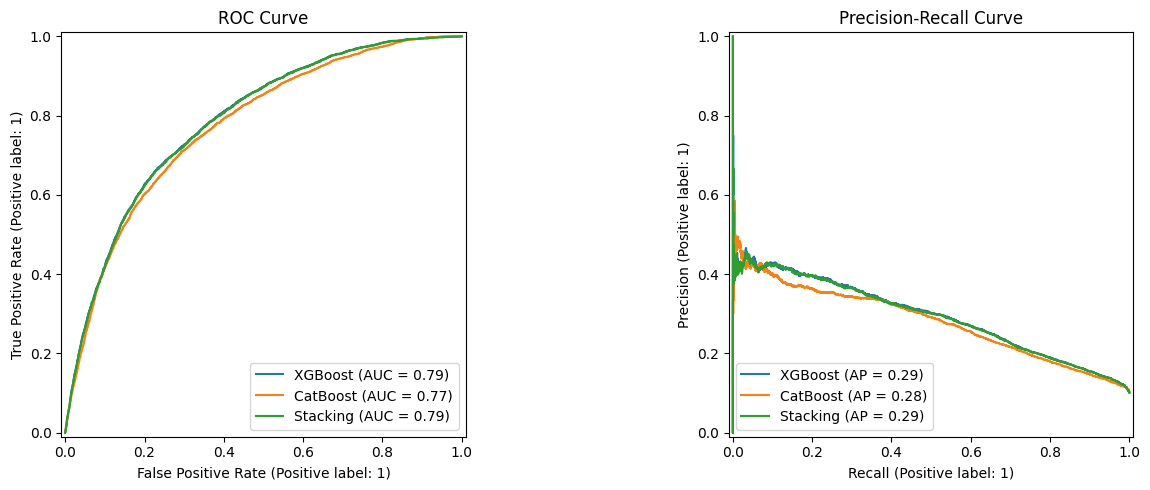

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba in [("XGBoost", p_xgb_val), ("CatBoost", p_cat_val), ("Stacking", p_stack)]:
    RocCurveDisplay.from_predictions(y_val_enc_nonorm, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_val_enc_nonorm.ravel(), proba, name=name, ax=axes[1])

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

In [36]:
#See results of coefficient of meta learner
meta_learner.coef_

array([[ 9.71097493, -0.5552615 ]])

#### Stacked regression logistic with three and four models

In [ ]:
#Let's retrieve the proba
p_rf_train  = rf_model.predict_proba(X_train_enc_nonorm)[:, 1]
p_lr_train  = reg_log_pipeline.predict_proba(X_train_enc_norm)[:, 1]
p_xgb_train = xgb_model.predict_proba(X_train_enc_nonorm)[:, 1]
p_cat_train = cat_pipeline.predict_proba(X_train_noenc_nonorm)[:, 1]

=== Seuils optimaux ===
XGBoost              Best threshold: 0.49 | F1: 0.3801 | Precision: 0.2922 | Recall: 0.5438
CatBoost             Best threshold: 0.51 | F1: 0.3695 | Precision: 0.2865 | Recall: 0.5200
Random Forest        Best threshold: 0.48 | F1: 0.3669 | Precision: 0.2902 | Recall: 0.4987
Log Reg              Best threshold: 0.67 | F1: 0.3532 | Precision: 0.2611 | Recall: 0.5456
Stack RF+XGB+CAT+LR  Best threshold: 0.09 | F1: 0.3026 | Precision: 0.2220 | Recall: 0.4751
Stack LR+XGB+CAT     Best threshold: 0.46 | F1: 0.3512 | Precision: 0.2924 | Recall: 0.4395

Model                      ROC-AUC   PR-AUC  Precision   Recall  Threshold
---------------------------------------------------------------------------
XGBoost                     0.7875   0.2938     0.2922   0.5438       0.49
CatBoost                    0.7742   0.2803     0.2865   0.5200       0.51
Random Forest               0.7794   0.2775     0.2902   0.4987       0.48
Log Reg                     0.7719   0.2625    

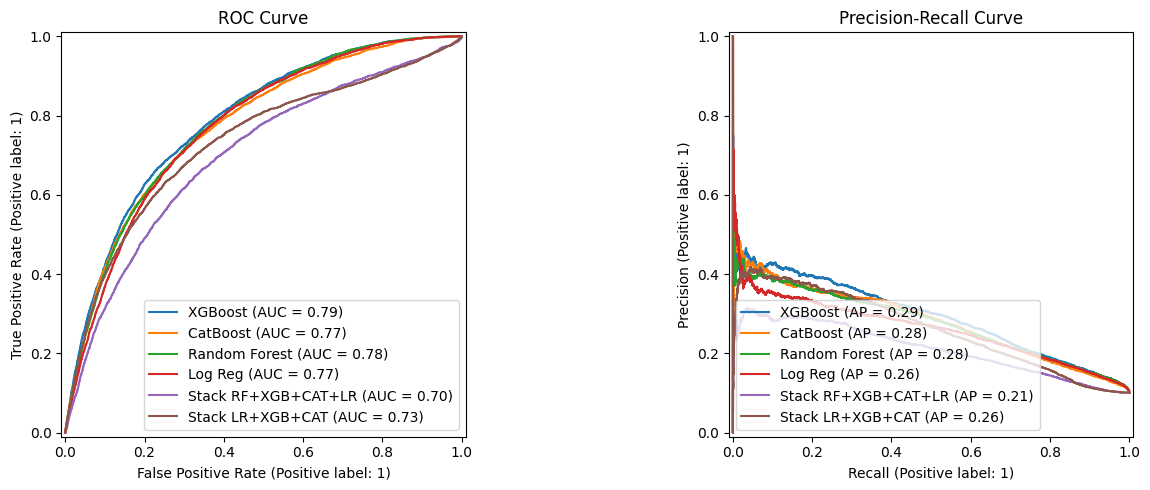

In [87]:
# ── Seuils optimaux ────────────────────────────────────────────────────────────
print("=== Seuils optimaux ===")
t_xgb = best_threshold_f1(y_val_enc_nonorm, p_xgb, "XGBoost")
t_cat = best_threshold_f1(y_val_enc_nonorm, p_cat, "CatBoost")
t_rf  = best_threshold_f1(y_val_enc_nonorm, p_rf,  "Random Forest")
t_lr  = best_threshold_f1(y_val_enc_norm,   p_lr,  "Log Reg")

# ── Meta-datasets ──────────────────────────────────────────────────────────────

# Combo 1 : RF + XGBoost + CatBoost + LR
X_meta_train_4 = np.column_stack([p_rf_train, p_xgb_train, p_cat_train, p_lr_train])
X_meta_val_4   = np.column_stack([p_rf,       p_xgb,       p_cat,       p_lr])

# Combo 2 : LR + XGBoost + CatBoost
X_meta_train_3 = np.column_stack([p_lr_train, p_xgb_train, p_cat_train])
X_meta_val_3   = np.column_stack([p_lr,       p_xgb,       p_cat])

# ── Fit meta-learners ──────────────────────────────────────────────────────────
meta_4 = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)
meta_4.fit(X_meta_train_4, y_train_enc_nonorm)

meta_3 = LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000)
meta_3.fit(X_meta_train_3, y_train_enc_nonorm)

# ── Probas stacking ────────────────────────────────────────────────────────────
p_stack_4 = meta_4.predict_proba(X_meta_val_4)[:, 1]
p_stack_3 = meta_3.predict_proba(X_meta_val_3)[:, 1]

t_stack_4 = best_threshold_f1(y_val_enc_nonorm, p_stack_4, "Stack RF+XGB+CAT+LR")
t_stack_3 = best_threshold_f1(y_val_enc_nonorm, p_stack_3, "Stack LR+XGB+CAT")

# ── Evaluation finale ──────────────────────────────────────────────────────────
print(f"\n{'Model':<25} {'ROC-AUC':>8} {'PR-AUC':>8} {'Precision':>10} {'Recall':>8} {'Threshold':>10}")
print("-" * 75)

results = [
    ("XGBoost",              p_xgb,     t_xgb,     y_val_enc_nonorm),
    ("CatBoost",             p_cat,     t_cat,     y_val_enc_nonorm),
    ("Random Forest",        p_rf,      t_rf,      y_val_enc_nonorm),
    ("Log Reg",              p_lr,      t_lr,      y_val_enc_nonorm),
    ("Stack RF+XGB+CAT+LR",  p_stack_4, t_stack_4, y_val_enc_nonorm),
    ("Stack LR+XGB+CAT",     p_stack_3, t_stack_3, y_val_enc_nonorm),
]

for name, proba, threshold, y in results:
    pred      = (proba >= threshold).astype(int)
    roc       = roc_auc_score(y, proba)
    pr        = average_precision_score(y, proba)
    precision = precision_score(y, pred)
    recall    = recall_score(y, pred)
    print(f"{name:<25} {roc:>8.4f} {pr:>8.4f} {precision:>10.4f} {recall:>8.4f} {threshold:>10.2f}")

# ── Meta-learner coefficients ──────────────────────────────────────────────────
print("\n=== Poids meta-learner : RF + XGB + CAT + LR ===")
for name, coef in zip(["RF", "XGBoost", "CatBoost", "LogReg"], meta_4.coef_[0]):
    print(f"  {name:<12} {coef:+.4f}")

print("\n=== Poids meta-learner : LR + XGB + CAT ===")
for name, coef in zip(["LogReg", "XGBoost", "CatBoost"], meta_3.coef_[0]):
    print(f"  {name:<12} {coef:+.4f}")

# ── ROC + PR curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, proba, _, y in results:
    RocCurveDisplay.from_predictions(y, proba, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y.ravel(), proba, name=name, ax=axes[1])

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")
plt.tight_layout()
plt.show()

The logistic regression stacked with three/four models has results that are worse than individual models on ROC-AUC, Recall and PrecisioN.

### Stacking with majority voting

Now, let's try to stack the models with a majority vote on Xgboost, Catboost and LogisticRegression/RandomForest.
First, let's test a threshold of 0.5 for each model.

In [ ]:
THRESHOLD = 0.5

def majority_vote(probas_list, y, names, threshold=THRESHOLD):
    # Convertir probas en prédictions binaires
    preds = np.column_stack([(p >= threshold).astype(int) for p in probas_list])
    
    # Vote majoritaire
    vote, _ = stats.mode(preds, axis=1)
    vote = vote.ravel()
    
    # Moyenne des probas pour les métriques ROC/PR
    mean_proba = np.mean(np.column_stack(probas_list), axis=1)
    
    auc       = roc_auc_score(y, mean_proba)
    ap        = average_precision_score(y, mean_proba)
    recall    = recall_score(y, vote)
    precision = precision_score(y, vote)
    
    combo_name = " + ".join(names)
    print(f"{'Majority Vote':<20} [{combo_name}]")
    print(f"{'':>20} ROC-AUC: {auc:.4f} | Avg Precision: {ap:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    return vote, mean_proba

# ── Combo 1 : RF + XGBoost + CatBoost ─────────────────────────────────────────
print("\n=== Majority Vote : RF + XGBoost + CatBoost ===")
vote_rf_xgb_cat, proba_rf_xgb_cat = majority_vote(
    probas_list = [p_rf,       p_xgb,      p_cat],
    y           = y_val_enc_nonorm,
    names       = ["RF",       "XGBoost",  "CatBoost"],
)

#Combo 2: LR + XGBoost + CatBoost
print("\n=== Majority Vote : LR + XGBoost + CatBoost ===")
vote_lr_xgb_cat, proba_lr_xgb_cat = majority_vote(
    probas_list = [p_lr,       p_xgb,      p_cat],
    y           = y_val_enc_nonorm,
    names       = ["Log Reg",  "XGBoost",  "CatBoost"],
)

print("\n=== Majority Vote : LR + XGBoost + CatBoost + RandomForest ===")
vote_lr_xgb_cat, proba_lr_xgb_cat = majority_vote(
    probas_list = [p_lr,       p_xgb,      p_cat, p_rf],
    y           = y_val_enc_nonorm,
    names       = ["Log Reg",  "XGBoost",  "CatBoost", "Random_Forest"],
)


=== Majority Vote : RF + XGBoost + CatBoost ===
Majority Vote        [RF + XGBoost + CatBoost]
                     ROC-AUC: 0.7888 | Avg Precision: 0.2939 | Recall: 0.5095 | Precision: 0.3021

=== Majority Vote : LR + XGBoost + CatBoost ===
Majority Vote        [Log Reg + XGBoost + CatBoost]
                     ROC-AUC: 0.7904 | Avg Precision: 0.2947 | Recall: 0.5864 | Precision: 0.2721

=== Majority Vote : LR + XGBoost + CatBoost + RandomForest ===
Majority Vote        [Log Reg + XGBoost + CatBoost + Random_Forest]
                     ROC-AUC: 0.7907 | Avg Precision: 0.2941 | Recall: 0.5067 | Precision: 0.3023


Now let's adapt the threshold of each model based on their performance (precision, recall)

In [91]:

def best_threshold_f1(y, proba, name):
    """Trouve le seuil qui maximise le F1"""
    precisions, recalls, thresholds = precision_recall_curve(y, proba)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1s)
    best_t   = thresholds[best_idx]
    print(f"{name:<20} Best threshold: {best_t:.2f} | F1: {f1s[best_idx]:.4f} | Precision: {precisions[best_idx]:.4f} | Recall: {recalls[best_idx]:.4f}")
    return best_t

print("=== Seuil optimal par modèle ===")
t_xgb   = best_threshold_f1(y_val_enc_nonorm, p_xgb,   "XGBoost")
t_cat   = best_threshold_f1(y_val_enc_nonorm, p_cat,   "CatBoost")
t_rf    = best_threshold_f1(y_val_enc_nonorm, p_rf,    "Random Forest")
t_lr   =   best_threshold_f1(y_val_enc_norm, p_lr,    "Logistic Regression")
t_stack = best_threshold_f1(y_val_enc_nonorm, p_stack, "Stacking")

=== Seuil optimal par modèle ===
XGBoost              Best threshold: 0.49 | F1: 0.3801 | Precision: 0.2922 | Recall: 0.5438
CatBoost             Best threshold: 0.51 | F1: 0.3695 | Precision: 0.2865 | Recall: 0.5200
Random Forest        Best threshold: 0.48 | F1: 0.3669 | Precision: 0.2902 | Recall: 0.4987
Logistic Regression  Best threshold: 0.67 | F1: 0.3532 | Precision: 0.2611 | Recall: 0.5456
Stacking             Best threshold: 0.57 | F1: 0.3800 | Precision: 0.2969 | Recall: 0.5277


In [92]:
def majority_vote(probas_list, y, names, thresholds):
    """
    thresholds : liste de seuils, un par modèle
    ex: [0.35, 0.42, 0.38]
    """
    # Chaque modèle vote avec son propre seuil
    preds = np.column_stack([
        (p >= t).astype(int) 
        for p, t in zip(probas_list, thresholds)
    ])
    
    vote, _ = stats.mode(preds, axis=1)
    vote = vote.ravel()
    
    mean_proba = np.mean(np.column_stack(probas_list), axis=1)
    
    auc       = roc_auc_score(y, mean_proba)
    ap        = average_precision_score(y, mean_proba)
    recall    = recall_score(y, vote)
    precision = precision_score(y, vote)

    combo_name = " + ".join(names)
    print(f"Majority Vote [{combo_name}]")
    print(f"Thresholds    {dict(zip(names, thresholds))}")
    print(f"ROC-AUC: {auc:.4f} | Avg Precision: {ap:.4f} | Recall: {recall:.4f} | Precision: {precision:.4f}")
    return vote, mean_proba


# ── Trouver les seuils optimaux ────────────────────────────────────────────────
t_xgb = best_threshold_f1(y_val_enc_nonorm, p_xgb, "XGBoost")
t_cat = best_threshold_f1(y_val_enc_nonorm, p_cat, "CatBoost")
t_rf  = best_threshold_f1(y_val_enc_nonorm, p_rf,  "Random Forest")

# ── Combo 1 : RF + XGBoost + CatBoost ─────────────────────────────────────────
print("\n=== Majority Vote : RF + XGBoost + CatBoost ===")
vote_rf_xgb_cat, _ = majority_vote(
    probas_list = [p_rf,  p_xgb,  p_cat],
    y           = y_val_enc_nonorm,
    names       = ["RF",  "XGBoost", "CatBoost"],
    thresholds  = [t_rf,  t_xgb,  t_cat],
)

# ── Combo 2 : LR + XGBoost + CatBoost ─────────────────────────────────────────
t_lr = best_threshold_f1(y_val_enc_norm, p_lr, "Log Reg")

print("\n=== Majority Vote : LR + XGBoost + CatBoost  ===")
vote_lr_xgb_cat, _ = majority_vote(
    probas_list = [p_lr,  p_xgb,  p_cat],
    y           = y_val_enc_nonorm,
    names       = ["LR",  "XGBoost", "CatBoost"],
    thresholds  = [t_lr,  t_xgb,  t_cat],
)

XGBoost              Best threshold: 0.49 | F1: 0.3801 | Precision: 0.2922 | Recall: 0.5438
CatBoost             Best threshold: 0.51 | F1: 0.3695 | Precision: 0.2865 | Recall: 0.5200
Random Forest        Best threshold: 0.48 | F1: 0.3669 | Precision: 0.2902 | Recall: 0.4987

=== Majority Vote : RF + XGBoost + CatBoost ===
Majority Vote [RF + XGBoost + CatBoost]
Thresholds    {'RF': np.float64(0.47720381088035196), 'XGBoost': np.float32(0.49350536), 'CatBoost': np.float64(0.51257000580793)}
ROC-AUC: 0.7888 | Avg Precision: 0.2939 | Recall: 0.5279 | Precision: 0.2982
Log Reg              Best threshold: 0.67 | F1: 0.3532 | Precision: 0.2611 | Recall: 0.5456

=== Majority Vote : LR + XGBoost + CatBoost  ===
Majority Vote [LR + XGBoost + CatBoost]
Thresholds    {'LR': np.float64(0.6718815372035197), 'XGBoost': np.float32(0.49350536), 'CatBoost': np.float64(0.51257000580793)}
ROC-AUC: 0.7904 | Avg Precision: 0.2947 | Recall: 0.5423 | Precision: 0.2935


The majority vote clearly improves the ROC-AUC. Let's try a last combo with all the four models.

In [133]:
print("\n=== Majority Vote : LR + XGBoost + CatBoost + RandomForest ===")
vote_lr_xgb_cat, _ = majority_vote(
    probas_list = [p_lr,  p_xgb,  p_cat, p_rf],
    y           = y_val_enc_nonorm,
    names       = ["LR",  "XGBoost", "CatBoost", "Random Forest"],
    thresholds  = [t_lr,  t_xgb,  t_cat, t_rf],
)


=== Majority Vote : LR + XGBoost + CatBoost + RandomForest ===
Majority Vote [LR + XGBoost + CatBoost + Random Forest]
Thresholds    {'LR': np.float64(0.6718815372035197), 'XGBoost': np.float32(0.49350536), 'CatBoost': np.float64(0.51257000580793), 'Random Forest': np.float64(0.47720381088035196)}
ROC-AUC: 0.7907 | Avg Precision: 0.2941 | Recall: 0.4926 | Precision: 0.3080


This is the best ROC-AUC we had so far, but the precision and recall are worse, so let's keep three models: Logistic Regression + XGBoost + CatBoost.

### Save stacking model

done with:
```bash
uv run python src/models/model_stack             
```